In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
with zipfile.ZipFile("archive.zip","r") as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [4]:
os.listdir("dataset")

['Global Superstore.csv']

In [6]:
df = pd.read_csv(
    "dataset/Global Superstore.csv",
    encoding="latin1"
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [7]:
df.head()

,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [8]:
print(df.shape)

(51290, 27)


In [9]:
df.isnull().sum()

,0
Category,0
City,0
Country,0
Customer ID,0
Customer Name,0
Discount,0
Market,0
ji_lu-shu,0
Order Date,0
Order ID,0


In [10]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent[missing_percent>0]

,0


In [11]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [12]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [13]:
print(df.isnull().sum().sum())

0


In [14]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :",duplicates)

Duplicate Rows : 0


In [15]:
df = df.drop_duplicates()

print(df.shape)

(51290, 27)


In [16]:
print(df.duplicated().sum())

0


In [17]:
df.dtypes

,0
Category,object
City,object
Country,object
Customer ID,object
Customer Name,object
Discount,float64
Market,object
ji_lu-shu,int64
Order Date,object
Order ID,object


In [19]:
df['Order Date'] = pd.to_datetime(
    df['Order Date']
)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  object        
 1   City            51290 non-null  object        
 2   Country         51290 non-null  object        
 3   Customer ID     51290 non-null  object        
 4   Customer Name   51290 non-null  object        
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  object        
 7   ji_lu-shu       51290 non-null  int64         
 8   Order Date      51290 non-null  datetime64[ns]
 9   Order ID        51290 non-null  object        
 10  Order Priority  51290 non-null  object        
 11  Product ID      51290 non-null  object        
 12  Product Name    51290 non-null  object        
 13  Profit          51290 non-null  float64       
 14  Quantity        51290 non-null  int64         
 15  Re

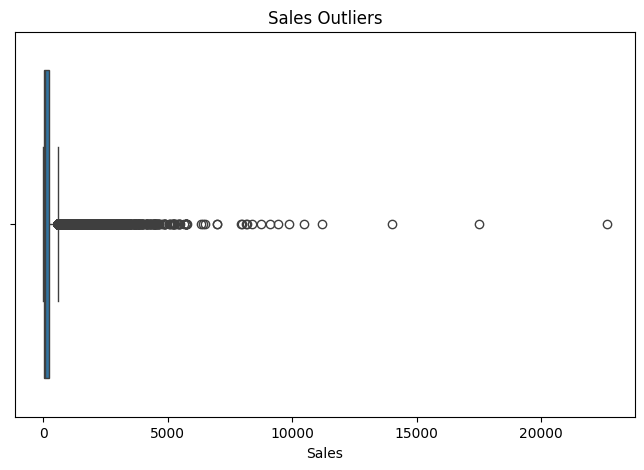

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Sales"])

plt.title("Sales Outliers")

plt.show()

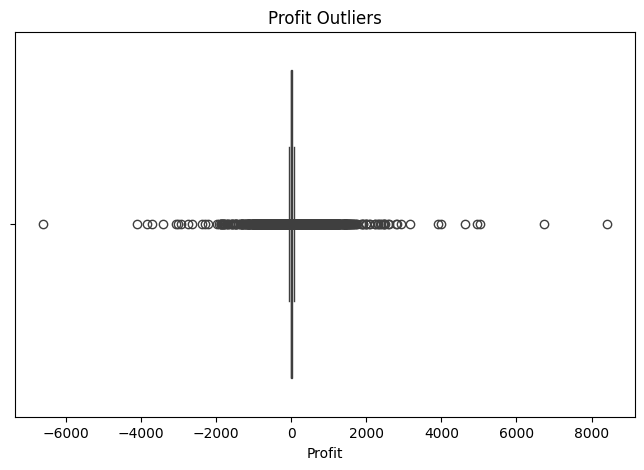

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Profit"])

plt.title("Profit Outliers")

plt.show()

In [24]:
Q1 = df["Sales"].quantile(0.25)

Q3 = df["Sales"].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR

upper = Q3+1.5*IQR

df = df[
    (df["Sales"]>=lower) &
    (df["Sales"]<=upper)
]

In [26]:
Q1 = df["Profit"].quantile(0.25)

Q3 = df["Profit"].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR

upper = Q3+1.5*IQR

df = df[
    (df["Profit"]>=lower) &
    (df["Profit"]<=upper)
]

In [27]:
print(df.shape)

(37703, 27)


In [28]:
df.isnull().sum()

,0
Category,0
City,0
Country,0
Customer ID,0
Customer Name,0
Discount,0
Market,0
ji_lu-shu,0
Order Date,0
Order ID,0


In [29]:
df.to_csv(
    "DataCo_Cleaned.csv",
    index=False
)

print("Cleaned Dataset Saved")

Cleaned Dataset Saved


In [30]:
from google.colab import files

files.download("DataCo_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

print("Null Values :",df.isnull().sum().sum())

print("Duplicate Rows :",df.duplicated().sum())

Rows : 37703
Columns : 27
Null Values : 0
Duplicate Rows : 0
